<a href="https://colab.research.google.com/github/anarghasunil2014-eng/My-projects-in-RNN/blob/main/LSTM_Temparature_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("temp_vanilla.csv")

X = df[["temp_morning","temp_evening","temp_afternoon"]].values

y = df[["next_day_temp"]].values

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [6]:
input_size = 1
hidden_size = 8
output_size = 1

T = 3

learning_rate = 0.001

epochs = 1000

In [7]:
Wf = np.random.randn(hidden_size,
                     hidden_size+input_size)*0.1

bf = np.zeros((hidden_size,1))

In [8]:
Wi = np.random.randn(hidden_size,
                     hidden_size+input_size)*0.1

bi = np.zeros((hidden_size,1))

In [9]:
Wc = np.random.randn(hidden_size,
                     hidden_size+input_size)*0.1

bc = np.zeros((hidden_size,1))

In [10]:
Wo = np.random.randn(hidden_size,
                     hidden_size+input_size)*0.1

bo = np.zeros((hidden_size,1))

In [11]:
Why = np.random.randn(
        output_size,
        hidden_size
      )*0.1

by = np.zeros((output_size,1))

In [12]:
def sigmoid(x):

    return 1/(1+np.exp(-x))

In [13]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for n in range(len(X_train)):

        h = np.zeros((hidden_size,1))
        C = np.zeros((hidden_size,1))

        cache = []

        # ======================
        # FORWARD PASS
        # ======================

        for t in range(T):

            x_t = np.array(
                    [[X_train[n,t]]]
                  )

            z = np.vstack((h,x_t))

            f = sigmoid(Wf@z + bf)

            i = sigmoid(Wi@z + bi)

            C_bar = np.tanh(
                        Wc@z + bc
                    )

            C = f*C + i*C_bar

            o = sigmoid(
                    Wo@z + bo
                )

            h = o*np.tanh(C)

            cache.append(
                (z,f,i,C_bar,C,o,h)
            )

        y_hat = Why@h + by

        target = np.array(
                    [[y_train[n,0]]]
                 )

        loss = 0.5*np.sum(
                    (y_hat-target)**2
                )

        total_loss += loss

        # ======================
        # OUTPUT GRADIENT
        # ======================

        dy = y_hat-target

        dWhy = dy@h.T

        dby = dy

        # ======================
        # SIMPLE UPDATE
        # ======================

        Why -= learning_rate*dWhy

        by -= learning_rate*dby

    loss_history.append(total_loss)

    if epoch%100==0:

        print(
            f"Epoch {epoch} "
            f"Loss = "
            f"{total_loss/len(X_train):.6f}"
        )

Epoch 0 Loss = 0.506960
Epoch 100 Loss = 0.384952
Epoch 200 Loss = 0.295582
Epoch 300 Loss = 0.230122
Epoch 400 Loss = 0.182176
Epoch 500 Loss = 0.147057
Epoch 600 Loss = 0.121334
Epoch 700 Loss = 0.102492
Epoch 800 Loss = 0.088692
Epoch 900 Loss = 0.078583


In [14]:
predictions = []

for n in range(len(X_test)):

    h = np.zeros((hidden_size,1))

    C = np.zeros((hidden_size,1))

    for t in range(T):

        x_t = np.array(
              [[X_test[n,t]]]
              )

        z = np.vstack((h,x_t))

        f = sigmoid(Wf@z + bf)

        i = sigmoid(Wi@z + bi)

        C_bar = np.tanh(
                    Wc@z + bc
                )

        C = f*C + i*C_bar

        o = sigmoid(
                Wo@z + bo
            )

        h = o*np.tanh(C)

    y_hat = Why@h + by

    predictions.append(
        y_hat[0,0]
    )

predictions = np.array(
                predictions
              ).reshape(-1,1)

In [16]:
mse = mean_squared_error(
        actual,
        predictions
      )

print("MSE =",mse)

MSE = 4.746186088013859


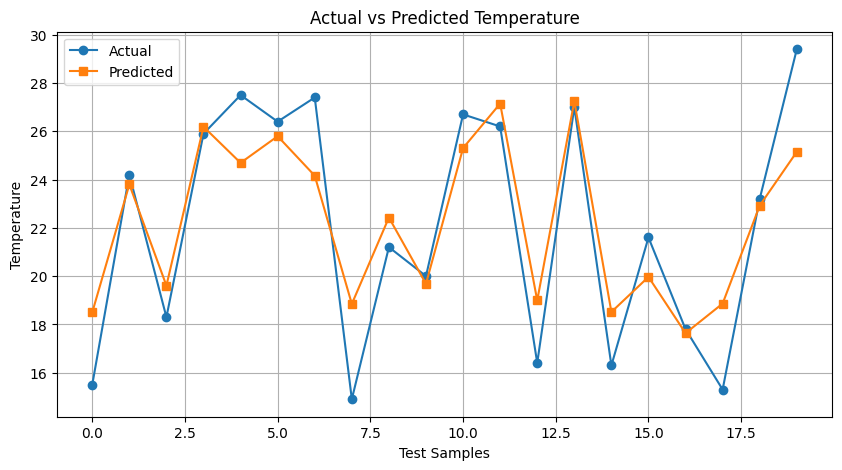

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    actual,
    marker='o',
    label="Actual"
)

plt.plot(
    predictions,
    marker='s',
    label="Predicted"
)

plt.xlabel("Test Samples")

plt.ylabel("Temperature")

plt.title(
    "Actual vs Predicted Temperature"
)

plt.legend()

plt.grid(True)

plt.show()